In [48]:
import matplotlib.pyplot as plt
import matplotlib.lines as lines
import numpy as np
from scipy.stats import beta
from sklearn import metrics

In [49]:
# Data
rng = np.random.default_rng(seed=42)

y_true = np.array(rng.integers(low=0, high=2, size=500))
y_probs = np.zeros(y_true.shape)

## Reference the $\beta$ (beta) distribution
https://numpy.org/doc/stable/reference/random/generated/numpy.random.beta.html
https://en.wikipedia.org/wiki/Beta_distribution

Here, we use the $\beta$ distribution to create something that looks like a noisy~ish classification model without need to specify a dataset or a model.
There is a deep literature in probability distributions. For a high level view, see [Wikipedia](https://en.wikipedia.org/wiki/Probability_distribution)

/tmp/ipykernel_539622/3465274427.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


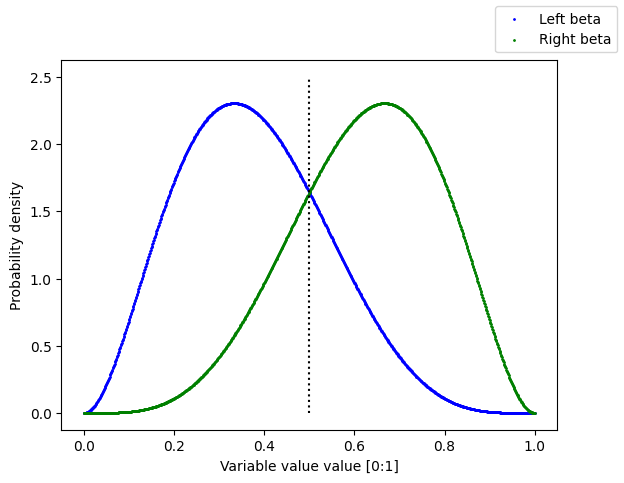

In [58]:
x = np.linspace(0, 1, 1000)
left_beta = beta.pdf(x, 3, 5)
right_beta = beta.pdf(x, 5, 3)
fig, ax = plt.subplots()
ax.scatter(x, left_beta, s=1, c="blue", label="Left beta")
ax.scatter(x, right_beta, s=1, c="green", label="Right beta")
ax.add_line(lines.Line2D([0.5, 0.5], [0, 2.5], linestyle=":", color="black"))
ax.set_xlabel("Variable value value [0:1]")
ax.set_ylabel("Probability density")
fig.legend()
fig.show()

In [20]:
for index, label in np.ndenumerate(y_true):
    if label == 0:
        y_probs[index] = rng.beta(3, 5)  # (2, 5)
    elif label == 1:
        y_probs[index] = rng.beta(5, 3)  # (4, 1)


In [31]:
# Generate a plot of ground truth vs. binary label
coupled_points = [(label, prob) for label, prob in zip(y_true, y_probs)]
coupled_points = sorted(coupled_points, key=lambda pair: pair[1], reverse=True)

true_point_y = [y[0] for y in coupled_points]
classification_prob_y = [y[1] for y in coupled_points]
all_x_points = [index for index in range(len(coupled_points))]

# Get the first false negative (i.e., left-most 0 in the sorted list)
first_false_positive = None
first_false_positive_index = None
for index, point_pair in enumerate(coupled_points):
    if point_pair[0] == 0:
        first_false_positive = point_pair
        first_false_positive_index = index
        break
first_false_positive_threshold = point_pair[1]
print(point_pair)

(np.int64(0), np.float64(0.7250408544407091))


/tmp/ipykernel_539622/3445937366.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


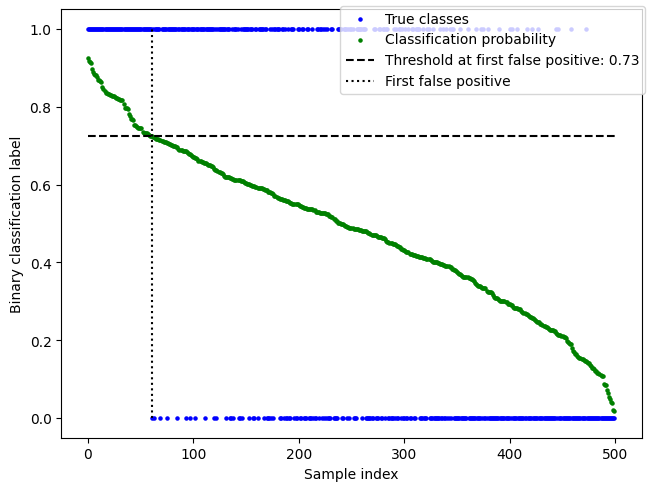

In [41]:
fig, ax = plt.subplots()
ax.scatter(all_x_points, true_point_y, c="blue", s=5, label="True classes")
ax.scatter(all_x_points, classification_prob_y, c="green", s=5, label="Classification probability")
ax.set_ylabel("Binary classification label")
ax.set_xlabel("Sample index")
ax.add_line(lines.Line2D(
    [0, 500], [first_false_positive_threshold, first_false_positive_threshold], linestyle="--", color="black",
    label=f"Threshold at first false positive: {first_false_positive_threshold:.2f}"
))
ax.add_line(lines.Line2D(
    [first_false_positive_index, first_false_positive_index], [0, 1], linestyle=":", color="black",
    label="First false positive"
))
fig.legend()
fig.set_layout_engine('constrained')
fig.show()

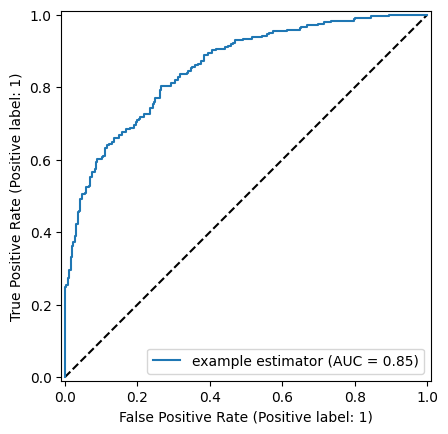

In [23]:
fpr, tpr, thresholds = metrics.roc_curve(y_true, y_probs)
roc_auc = metrics.auc(fpr, tpr)
fig, ax = plt.subplots()
random_line = lines.Line2D([0, 1], [0, 1], color='black', linestyle="--")
ax.add_line(random_line)
display = metrics.RocCurveDisplay.from_predictions(y_true, y_score=y_probs, ax=ax, name='example estimator')


In [24]:
j_scores = tpr - fpr

optimal_index = np.argmax(j_scores)
optimal_j = j_scores[optimal_index]

optimal_threshold = thresholds[optimal_index]
optimal_tpr = tpr[optimal_index]
optimal_fpr = fpr[optimal_index]


# print(f"{optimal_tpr} :: {optimal_fpr} :: {optimal_threshold}")

In [25]:
precision, recall, thresholds_PR = metrics.precision_recall_curve(y_true, y_probs)

Optimal TPR: 0.80 | Optimal FPR: 0.27


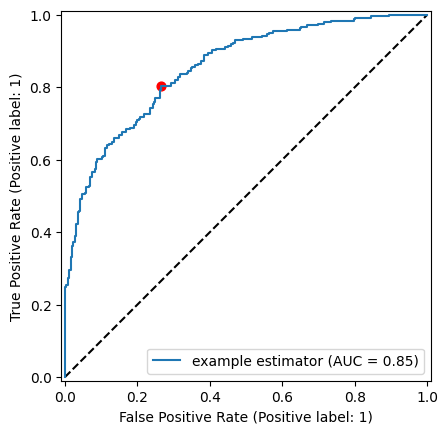

In [44]:
fig2, ax2 = plt.subplots()
ax2.scatter(optimal_fpr, optimal_tpr, color='red', marker='o', s=40)
random_line = lines.Line2D([0, 1], [0, 1], color='black', linestyle="--")
ax2.add_line(random_line)
display2 = metrics.RocCurveDisplay.from_predictions(y_true, y_score=y_probs, ax=ax2, name='example estimator')
print(f"Optimal TPR: {optimal_tpr:.2f} | Optimal FPR: {optimal_fpr:.2f}")


/tmp/ipykernel_539622/3230224337.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


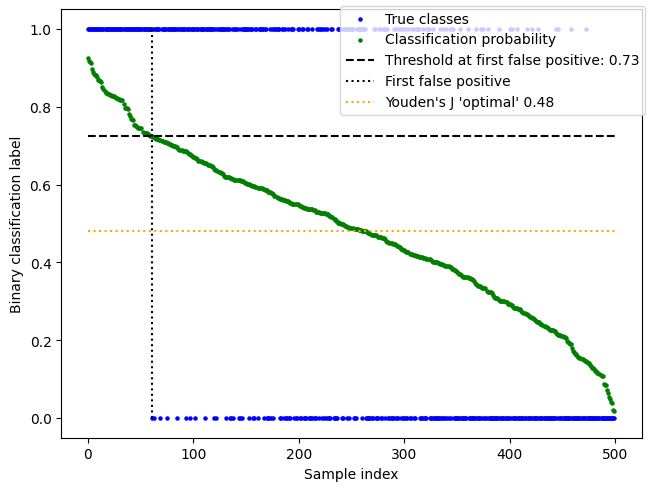

In [42]:
fig, ax = plt.subplots()
ax.scatter(all_x_points, true_point_y, c="blue", s=5, label="True classes")
ax.scatter(all_x_points, classification_prob_y, c="green", s=5, label="Classification probability")
ax.set_ylabel("Binary classification label")
ax.set_xlabel("Sample index")
ax.add_line(lines.Line2D(
    [0, 500], [first_false_positive_threshold, first_false_positive_threshold], linestyle="--", color="black",
    label=f"Threshold at first false positive: {first_false_positive_threshold:.2f}"
))
ax.add_line(lines.Line2D(
    [first_false_positive_index, first_false_positive_index], [0, 1], linestyle=":", color="black",
    label="First false positive"
))
ax.add_line(lines.Line2D(
    [0, 500], [optimal_threshold, optimal_threshold], linestyle=":", color="orange",
    label=f"Youden's J 'optimal' {optimal_threshold:.2f}"
))
fig.legend()
fig.set_layout_engine('constrained')
fig.show()